In [1]:
import requests
import matplotlib.pyplot as plt
import pandas as pd
import time
from tqdm import tqdm
import re
import spacy
import numpy as np
from spacy.matcher import PhraseMatcher

In [2]:
# import sys
# !{sys.executable} -m pip install requests pandas tqdm spacy numpy

## Data Acquisition

In [3]:
API_KEY = "84287db0-182f-4d1b-9d8e-3c2047664fe4"

In [4]:
BASE_URL = "https://content.guardianapis.com/search"

params = {
    "api-key": API_KEY,
    "section": "business",
    "from-date": "2019-01-01",
    "to-date": "2025-12-31",
    "show-fields": "bodyText,headline,byline",
    "show-tags": "type,keyword,tone",
    "page-size": 50,   # maximum allowed
    "page": 1
}

In [5]:
response = requests.get(BASE_URL, params=params)

print("Status code:", response.status_code)
print(response.url)

data = response.json()

Status code: 200
https://content.guardianapis.com/search?api-key=84287db0-182f-4d1b-9d8e-3c2047664fe4&section=business&from-date=2019-01-01&to-date=2025-12-31&show-fields=bodyText%2Cheadline%2Cbyline&show-tags=type%2Ckeyword%2Ctone&page-size=50&page=1


In [6]:
all_articles = []

# First request to get total pages
response = requests.get(BASE_URL, params=params)
data = response.json()

total_pages = data["response"]["pages"]
print(f"Total pages in 2019-2024 in business section: {total_pages}")

for page in tqdm(range(1, total_pages + 1)):
    params["page"] = page
    
    response = requests.get(BASE_URL, params=params)
    data = response.json()
    
    articles = data["response"]["results"]
    
    for article in articles:
        fields = article.get("fields", {})
        
        all_articles.append({
            "webTitle": article.get("webTitle"),
            "sectionName": article.get("sectionName"),
            "webPublicationDate": article.get("webPublicationDate"),
            "headline": fields.get("headline"),
            "byline": fields.get("byline"),
            "bodyText": fields.get("bodyText"),
            "tags": article.get("tags"),
            "webUrl": article.get("webUrl")
        })
    
    time.sleep(1)

Total pages in 2019-2024 in business section: 523


100%|████████████████████████████████████████████████████████████████████████████████| 523/523 [10:52<00:00,  1.25s/it]


In [7]:
df = pd.DataFrame(all_articles)

print("Total articles pulled:", len(df))

Total articles pulled: 26133


In [8]:
df.head()

,webTitle,sectionName,webPublicationDate,headline,byline,bodyText,tags,webUrl
0,Wall Street ends 2025 near record highs after ...,Business,2025-12-31T21:15:13Z,Wall Street ends 2025 near record highs after ...,Callum Jones in New York,Wall Street finished 2025 near record highs on...,"[{'id': 'business/stock-markets', 'type': 'key...",https://www.theguardian.com/business/2025/dec/...
1,Waitrose urges customers not to drink Deeside ...,Business,2025-12-31T17:21:16Z,Waitrose urges customers not to drink Deeside ...,Kalyeena Makortoff,Waitrose customers are being urged to return a...,"[{'id': 'business/waitrose', 'type': 'keyword'...",https://www.theguardian.com/business/2025/dec/...
2,Eurostar slowly resumes but passengers face mo...,Business,2025-12-31T16:02:01Z,Eurostar slowly resumes but passengers face mo...,Caroline Davies and agency,Rail traffic through the Channel tunnel slowly...,"[{'id': 'business/eurostar', 'type': 'keyword'...",https://www.theguardian.com/business/2025/dec/...
3,ITV agrees to invest £3m in fitness app create...,Business,2025-12-31T15:35:29Z,ITV agrees to invest £3m in fitness app create...,Joanna Partridge,The broadcaster ITV has agreed to invest up to...,"[{'id': 'business/itv', 'type': 'keyword', 'se...",https://www.theguardian.com/media/2025/dec/31/...
4,London stock exchange beats Wall Street with b...,Business,2025-12-31T15:31:10Z,London stock exchange beats Wall Street with b...,Graeme Wearden,Britain’s stock market has increased in value ...,"[{'id': 'business/ftse', 'type': 'keyword', 's...",https://www.theguardian.com/business/2025/dec/...


In [9]:
row = df.iloc[0]

for col in df.columns:
    print(f"{col}: {row[col]}")

webTitle: Wall Street ends 2025 near record highs after year of economic upheaval
sectionName: Business
webPublicationDate: 2025-12-31T21:15:13Z
headline: Wall Street ends 2025 near record highs after year of economic upheaval
byline: Callum Jones in New York
bodyText: Wall Street finished 2025 near record highs on Wednesday, as ballooning tech valuations and hopes of lower interest rates helped stock markets defy a year of economic uncertainty. The benchmark S&amp;P 500 rose 16.4% over the course of the year, closing at 6,845.50 on New Year’s Eve in New York, as investors largely shrugged off geopolitical uncertainty and the frenzy around artificial intelligence continued. It fell 0.7% during Wednesday’s trading session. Other global indices had an even stronger year. In London, the FTSE 100 enjoyed its biggest annual gain since 2009, advancing 21.5%. The Dow Jones Industrial Average gained 13.4% during 2025. The tech-focused Nasdaq Composite rallied 20.5%. Donald Trump’s aggressive p

## Exploratory Data Analysis (EDA)

In [10]:
df.describe(include="all")

,webTitle,sectionName,webPublicationDate,headline,byline,bodyText,tags,webUrl
count,26133,26133,26133,26133,25942,26133,26133,26133
unique,26116,1,25676,26116,2499,26129,25043,26133
top,UK inflation: which goods and services have ch...,Business,2019-06-26T16:00:19Z,UK inflation: which goods and services have ch...,Sarah Butler,,"[{'id': 'business/retail', 'type': 'keyword', ...",https://www.theguardian.com/business/2019/jan/...
freq,9,26133,5,9,1608,5,53,1


In [11]:
print("Total Authors:", df["byline"].nunique())

Total Authors: 2499


In [12]:
print("Most Frequent Authors")
print(df["byline"].value_counts().head(10))
print("*" * 15)
print("Least Frequent Authors")
print(df["byline"].value_counts().tail(10))

Most Frequent Authors
byline
Sarah Butler                                  1608
Jasper Jolly                                  1402
Graeme Wearden                                1279
Julia Kollewe                                 1148
Nils Pratley                                  1039
Phillip Inman                                  978
Mark Sweney                                    950
Richard Partington Economics correspondent     816
Kalyeena Makortoff Banking correspondent       783
Rob Davies                                     669
Name: count, dtype: int64
***************
Least Frequent Authors
byline
Phillip Inman and Lily Kuo in Beijing                    1
Stephen Koukoulas                                        1
Jasper Jolly  and agencies                               1
Larry Elliott, Graeme Wearden and Kalyeena Makortoff     1
Larry Elliott, Heather Stewart and Kalyeena Makortoff    1
Kalyeena Makortoff in Davos                              1
Julia Kollewe and Amy Walker       

In [13]:
len(df[df["byline"].str.contains(" and ", na=False)]["byline"].value_counts())

1463

In [14]:
df[df["byline"].str.contains(" and ", na=False)]["byline"].value_counts().head(5)

byline
Guardian staff and agencies                            70
Elias Visontay Transport and urban affairs reporter    59
Jasper Jolly and agencies                              41
Guardian staff and agency                              30
Staff and agencies                                     27
Name: count, dtype: int64

In [15]:
df[df["byline"].str.contains(" and ", na=False)]["byline"].value_counts().tail(5)

byline
Kiran Stacey and Kalyeena Makortoff                1
Graeme Wearden in Davos (now) and Julia Kollewe    1
Zoe Wood,  Angela Monaghan and Amy Walker          1
Rob Davies and Dominic Rushe                       1
Jasper Jolly  and Rob Davies                       1
Name: count, dtype: int64

In [16]:
df["byline"].isna().sum()

np.int64(191)

In [17]:
(df["byline"] == "").sum()

np.int64(76)

In [18]:
df["year"] = pd.to_datetime(df["webPublicationDate"]).dt.year

author_by_year = df.groupby("year")["byline"].nunique()
print(author_by_year)

year
2019    483
2020    545
2021    554
2022    625
2023    593
2024    555
2025    582
Name: byline, dtype: int64


In [19]:
df.groupby("year").size()

year
2019    3605
2020    4244
2021    3989
2022    4069
2023    3654
2024    3463
2025    3109
dtype: int64

In [20]:
df.to_csv("guardian_business_raw.csv", index=False)

# DATA CLEANING

In [21]:
## PARAMETERS
author_min_freq = int(0.001 * len(df)) # Approximately holds atleast 1% of the sample

In [22]:
def clean_authors(df, min_freq=5):
    df = df.copy()
    
    # Remove nulls
    df = df[df["byline"].notna()]
    
    # Remove empty or whitespace-only strings
    df = df[df["byline"].str.strip() != ""]
    
    # Compute author frequencies
    author_counts = df["byline"].value_counts()
    
    # Keep only authors with freq >= min_freq
    valid_authors = author_counts[author_counts >= min_freq].index
    
    df = df[df["byline"].isin(valid_authors)]
    
    return df

In [23]:
df_filtered = clean_authors(df, author_min_freq)

print("Before:", len(df))
print("After:", len(df_filtered))

Before: 26133
After: 20360


In [24]:
print("Most Frequent Authors")
print(df_filtered["byline"].value_counts().head(10))
print("*" * 15)
print("Least Frequent Authors")
print(df_filtered["byline"].value_counts().tail(10))

Most Frequent Authors
byline
Sarah Butler                                  1608
Jasper Jolly                                  1402
Graeme Wearden                                1279
Julia Kollewe                                 1148
Nils Pratley                                  1039
Phillip Inman                                  978
Mark Sweney                                    950
Richard Partington Economics correspondent     816
Kalyeena Makortoff Banking correspondent       783
Rob Davies                                     669
Name: count, dtype: int64
***************
Least Frequent Authors
byline
Ben Smee                                     32
Jon Ungoed-Thomas                            31
Tom Ambrose                                  31
Jennifer Rankin in Brussels                  30
Guardian staff and agency                    30
Jonathan Barrett Senior business reporter    30
Staff and agencies                           27
Jedidajah Otte                               26
Katha

In [25]:
unique_bylines = sorted(df_filtered["byline"].dropna().unique())
print(unique_bylines)

['Alex Lawson', 'Alex Lawson Energy correspondent', 'Amy Remeikis', 'Angela Monaghan', 'Anna Isaac', 'Ben Butler', 'Ben Smee', 'Callum Jones in New York', 'Dan Milmo Global technology editor', 'Dominic Rushe', 'Dominic Rushe in New York', 'Edward Helmore', 'Edward Helmore in New York', 'Elias Visontay', 'Elias Visontay Transport and urban affairs reporter', 'Gene Marks', 'Graeme Wearden', 'Greg Jericho', 'Guardian community team', 'Guardian staff and agencies', 'Guardian staff and agency', 'Gwyn Topham', 'Gwyn Topham Transport correspondent', 'Heather Stewart', 'Heather Stewart Economics editor', 'Helena Horton Environment reporter', 'Henry Belot', 'Hilary Osborne', 'Jack Simpson', 'Jane Croft', 'Jasper Jolly', 'Jasper Jolly and agencies', 'Jedidajah Otte', 'Jennifer Rankin in Brussels', 'Jillian Ambrose', 'Jillian Ambrose Energy correspondent', 'Joanna Partridge', 'Joe Middleton', 'Jon Ungoed-Thomas', 'Jonathan Barrett', 'Jonathan Barrett Senior business reporter', 'Josh Taylor', 'Jul

In [26]:
# Bylines with job titles
title_mask = df_filtered["byline"].str.contains(
    r"correspondent|reporter|editor|writer|analyst|columnist",
    case=False,
    na=False
)

title_patterns = sorted(df_filtered.loc[title_mask, "byline"].dropna().unique())
print("Bylines with job titles:")
print(title_patterns)

Bylines with job titles:
['Alex Lawson Energy correspondent', 'Dan Milmo Global technology editor', 'Elias Visontay Transport and urban affairs reporter', 'Gwyn Topham Transport correspondent', 'Heather Stewart Economics editor', 'Helena Horton Environment reporter', 'Jillian Ambrose Energy correspondent', 'Jonathan Barrett Senior business reporter', 'Kalyeena Makortoff Banking correspondent', 'Katharine Murphy Political editor', 'Larry Elliott Economics editor', 'Peter Hannam Economics correspondent', 'Rebecca Smithers Consumer affairs correspondent', 'Richard Partington Economics correspondent', 'Richard Partington Senior economics correspondent', 'Rupert Neate Wealth correspondent']


In [27]:
# Bylines with multiple authors
multi_author_mask = df_filtered["byline"].str.contains(r" and | & ", na=False)
multi_author = sorted(df_filtered.loc[multi_author_mask, "byline"].dropna().unique())
print("Bylines with multiple authors:")
print(multi_author)

Bylines with multiple authors:
['Elias Visontay Transport and urban affairs reporter', 'Guardian staff and agencies', 'Guardian staff and agency', 'Jasper Jolly and agencies', 'Staff and agencies']


In [28]:
# Summary counts
print("Total unique bylines:", df_filtered["byline"].nunique())
print("Bylines with job titles:", len(title_patterns))
print("Bylines with multiple authors:", len(multi_author))

Total unique bylines: 80
Bylines with job titles: 16
Bylines with multiple authors: 5


In [29]:
df_filtered["author"] = df_filtered["byline"].copy()

# Cleaning common suffixes
df_filtered["author"] = (
    df_filtered["author"]
    .str.replace(r"\s+in New York$", "", regex=True)
    .str.replace(r"\s+in Brussels$", "", regex=True)
    .str.replace(r"\s+Senior business reporter$", "", regex=True)
    .str.replace(r"\s+Senior economics correspondent$", "", regex=True)
    .str.replace(r"\s+Economics correspondent$", "", regex=True)
    .str.replace(r"\s+Energy correspondent$", "", regex=True)
    .str.replace(r"\s+Banking correspondent$", "", regex=True)
    .str.replace(r"\s+Political editor$", "", regex=True)
    .str.replace(r"\s+Economics editor$", "", regex=True)
    .str.replace(r"\s+Environment reporter$", "", regex=True)
    .str.replace(r"\s+Transport correspondent$", "", regex=True)
    .str.replace(r"\s+Transport and urban affairs reporter$", "", regex=True)
    .str.replace(r"\s+Consumer affairs correspondent$", "", regex=True)
    .str.replace(r"\s+Social affairs correspondent$", "", regex=True)
    .str.replace(r"\s+Wealth correspondent$", "", regex=True)
    .str.replace(r"\s+Global technology editor$", "", regex=True)
    .str.replace(r"\s+and agencies$", "", regex=True)
    .str.strip()
)

In [30]:
# Remove institutional bylines
institutional = {
    "Guardian community team",
    "Guardian staff and agencies",
    "Guardian staff and agency",
    "Staff and agencies",
    "Letters",
    "Guardian staff",
    "Staff"
}

df_filtered = df_filtered.loc[~df_filtered["author"].isin(institutional)].copy()

In [31]:
# Removing rows without authors
df_filtered = df_filtered.loc[df_filtered["author"].notna()].copy()
df_filtered = df_filtered.loc[df_filtered["author"].str.strip() != ""].copy()

In [34]:
df_filtered["year"] = pd.to_datetime(df_filtered["webPublicationDate"]).dt.year
df_filtered["month"] = pd.to_datetime(df_filtered["webPublicationDate"]).dt.month
df_filtered["day"] = pd.to_datetime(df_filtered["webPublicationDate"]).dt.day
df_filtered["date"] = pd.to_datetime(df_filtered["webPublicationDate"]).dt.tz_localize(None)
df_filtered["tm"] = (
    (df_filtered["date"] - pd.Timestamp("2019-01-01"))
    .dt.days / 30
)
df_filtered["post"] = (df_filtered["date"] >= "2022-11-01").astype(int)

In [35]:
# Compute author coverage (how many periods each author appears in)
author_coverage = df_filtered.groupby("author")["post"].nunique()

# Keep only authors present in BOTH periods
authors_both_periods = author_coverage[author_coverage == 2].index
df_filtered = df_filtered[df_filtered["author"].isin(authors_both_periods)].copy()

# Summary output
print("\nAfter removing single-period authors:")
print("  Articles:", len(df_filtered))
print("  Authors:", df_filtered["author"].nunique())
print("  Pre-ChatGPT articles:", (df_filtered["post"] == 0).sum())
print("  Post-ChatGPT articles:", (df_filtered["post"] == 1).sum())
print("  Year range:", df_filtered["year"].min(), "-", df_filtered["year"].max())


After removing single-period authors:
  Articles: 19026
  Authors: 47
  Pre-ChatGPT articles: 11522
  Post-ChatGPT articles: 7504
  Year range: 2019 - 2025


In [36]:
print("Unique authors after cleaning:", df_filtered["author"].nunique())
print("Total articles remaining:", len(df_filtered))
print(df_filtered["author"].unique())

Unique authors after cleaning: 47
Total articles remaining: 19026
['Kalyeena Makortoff' 'Joanna Partridge' 'Graeme Wearden' 'Lauren Aratani'
 'Nils Pratley' 'Jasper Jolly' 'Zoe Wood' 'Rob Davies' 'Simon Goodley'
 'Richard Partington' 'Jillian Ambrose' 'Phillip Inman' 'Julia Kollewe'
 'Mark Sweney' 'Gene Marks' 'Gwyn Topham' 'Sarah Butler' 'Dominic Rushe'
 'Heather Stewart' 'Rupert Jones' 'Greg Jericho' 'Michael Sainato'
 'Helena Horton' 'Edward Helmore' 'Jedidajah Otte' 'Sandra Laville'
 'Sarah Marsh' 'Dan Milmo' 'Josh Taylor' 'Hilary Osborne' 'Alex Lawson'
 'Jennifer Rankin' 'William Keegan' 'Elias Visontay' 'Jon Ungoed-Thomas'
 'Peter Hannam' 'Tom Ambrose' 'Larry Elliott' 'Miles Brignall'
 'Rupert Neate' 'Amy Remeikis' 'Martin Farrer' 'Katharine Murphy'
 'Angela Monaghan' 'Joe Middleton' 'Paul Karp' 'Patrick Collinson']


In [37]:
df_filtered["author_id"] = pd.factorize(df_filtered["author"])[0]

In [38]:
def has_tone(tag_list, tone_id):
    if not isinstance(tag_list, list):
        return False
    return any(tag.get("id") == tone_id for tag in tag_list)

def has_type(tag_list, type_id):
    if not isinstance(tag_list, list):
        return False
    return any(tag.get("id") == type_id for tag in tag_list)

In [39]:
# Removing unwanted tones
df_filtered = df_filtered[
    ~df_filtered["tags"].apply(lambda x: has_tone(x, "tone/minutebyminute")) &
    ~df_filtered["tags"].apply(lambda x: has_tone(x, "tone/comment"))
]

In [40]:
# Keeping only type/articles
df_filtered = df_filtered[
    df_filtered["tags"].apply(lambda x: has_type(x, "type/article"))
]

In [41]:
# Removing /live/ urls
df_filtered = df_filtered[
    ~df_filtered["webUrl"].str.contains("/live/", na=False)
]

In [42]:
df_clean = df_filtered.copy()

In [43]:
author_by_year = df_clean.groupby("year")["byline"].nunique()
print(author_by_year)

year
2019    44
2020    47
2021    50
2022    54
2023    58
2024    50
2025    43
Name: byline, dtype: int64


In [44]:
df_clean.groupby("year").size()

year
2019    1952
2020    2512
2021    2393
2022    2473
2023    2169
2024    1756
2025    1594
dtype: int64

In [45]:
clean_counts = df_clean.groupby("year").size()
raw_counts = df.groupby("year").size()

difference = raw_counts - clean_counts
print(difference)

year
2019    1653
2020    1732
2021    1596
2022    1596
2023    1485
2024    1707
2025    1515
dtype: int64


In [46]:
df_clean.describe(include="all")

,webTitle,sectionName,webPublicationDate,headline,byline,bodyText,tags,webUrl,year,author,month,day,date,tm,post,author_id
count,14849,14849,14849,14849,14849,14849,14849,14849,14849.000000,14849,14849.000000,14849.000000,14849,14849.000000,14849.000000,14849.000000
unique,14835,1,14628,14835,61,14849,14408,14849,NaN,46,NaN,NaN,NaN,NaN,NaN,NaN
top,UK inflation: which goods and services have ch...,Business,2019-06-26T16:00:19Z,UK inflation: which goods and services have ch...,Sarah Butler,Britain’s biggest listed companies will be for...,"[{'id': 'business/retail', 'type': 'keyword', ...",https://www.theguardian.com/business/2019/jan/...,NaN,Sarah Butler,NaN,NaN,NaN,NaN,NaN,NaN
freq,8,14849,4,8,1608,1,48,1,NaN,1608,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021.810762,NaN,6.444946,15.636406,2022-04-21 23:08:29.296720384,40.214039,0.397400,13.845781
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,1.000000,1.000000,2019-01-01 00:01:06,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000,NaN,3.000000,8.000000,2020-09-01 08:26:28,20.300000,0.000000,6.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022.000000,NaN,6.000000,16.000000,2022-03-26 06:00:48,39.333333,0.000000,12.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.000000,NaN,9.000000,23.000000,2023-11-01 05:00:32,58.833333,1.000000,16.000000
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025.000000,NaN,12.000000,31.000000,2025-12-31 17:21:16,85.200000,1.000000,46.000000


In [47]:
row = df_clean.iloc[0]

for col in df_clean.columns:
    print(f"{col}: {row[col]}")

webTitle: Waitrose urges customers not to drink Deeside water over shards of glass risk
sectionName: Business
webPublicationDate: 2025-12-31T17:21:16Z
headline: Waitrose urges customers not to drink Deeside water over shards of glass risk
byline: Kalyeena Makortoff
bodyText: Waitrose customers are being urged to return and not drink large bottles of Deeside mineral water over fears they could contain shards of glass. The Food Standards Agency (FSA) has issued a consumer alert over the still and sparkling 750ml bottles of Waitrose No 1 Deeside mineral water because of the possibility of glass fragments, making them unsafe to drink. The potentially contaminated mineral waters, which are bottled specially for Waitrose from a spring near Balmoral Castle in Scotland’s Cairngorms national park, cost about £1.60 each in store. The supermarket has removed the bottles from its shelves and customers who have already bought them are being asked to call the retailer or return the product in person

In [48]:
df_clean.to_csv("guardian_business_clean.csv", index=False)

## DATA PREPROCESSING

In [49]:
df_clean = pd.read_csv("guardian_business_clean.csv")
# Restore datetime
df_clean["date"] = pd.to_datetime(df_clean["date"])

In [50]:
def clean_text(text):
    if pd.isna(text):
        return None
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)
    
    # Fix HTML entities like &amp;
    text = text.replace("&amp;", "&")
    
    return text.strip()

df_clean["clean_text"] = df_clean["bodyText"].apply(clean_text)

In [51]:
# !python -m pip install en_core_web_sm --find-links https://github.com/explosion/spacy-models/releases/expanded_assets/en_core_web_sm-3.8.0

In [52]:
nlp = spacy.load("en_core_web_sm", disable=["ner"])

docs = list(nlp.pipe(df_clean["clean_text"], batch_size=50))

In [53]:
# Hedge Token List — Hyland (2005)
# Hyland, K. (2005). Metadiscourse. Continuum.

HEDGE_TOKENS = {
    # Epistemic modal verbs
    "may", "might", "could", "would", "should",
    # Epistemic adverbs
    "perhaps", "possibly", "probably", "apparently",
    "presumably", "seemingly", "arguably", "generally",
    "typically", "usually", "often", "sometimes",
    # Approximators
    "about", "around", "approximately", "roughly",
    "nearly", "almost", "somewhat",
    # Attribution verbs (lemma form)
    "suggest", "indicate", "appear", "seem", "tend",
    "assume", "believe", "imply",
    # Adjective/noun hedges
    "possible", "probable", "likely", "uncertain",
    "unclear", "approximate"
}


In [54]:
hedge_counts = []
n_sentences = []
word_counts = []
avg_sentence_lengths = []
burstiness_scores = []
ttr_scores = []

for doc in docs:
    
    sentences = list(doc.sents)
    sentence_lengths = []
    hedge_count = 0
    tokens_for_ttr = []
    
    for sent in sentences:
        length = 0
        for token in sent:
            if token.is_space or token.is_punct:
                continue
            
            length += 1
            # Store lowercase lemma/text for TTR
            tok = token.lemma_.lower() if token.lemma_ else token.text.lower()
            tokens_for_ttr.append(tok)
            
            # Hedge detection using lemma (cleaner than raw text)
            if token.lemma_.lower() in HEDGE_TOKENS:
                hedge_count += 1
        
        sentence_lengths.append(length)
    
    n_sent = len(sentence_lengths)
    total_words = sum(sentence_lengths)
    
    n_sentences.append(n_sent)
    word_counts.append(total_words)
    hedge_counts.append(hedge_count)

     # TTR
    if total_words > 0:
        ttr_scores.append(len(set(tokens_for_ttr)) / total_words)
    else:
        ttr_scores.append(np.nan)
    
    if n_sent > 0:
        avg_len = total_words / n_sent
        avg_sentence_lengths.append(avg_len)
        
        if avg_len > 0:
            burstiness_scores.append(np.std(sentence_lengths) / avg_len)
        else:
            burstiness_scores.append(np.nan)
    else:
        avg_sentence_lengths.append(np.nan)
        burstiness_scores.append(np.nan)

In [55]:
df_clean["n_sentences"] = n_sentences
df_clean["word_count"] = word_counts
df_clean["avg_sentence_length"] = avg_sentence_lengths
df_clean["burstiness"] = burstiness_scores
df_clean["hedge_count"] = hedge_counts
df_clean["hedge_rate"] = (df_clean["hedge_count"] / df_clean["word_count"]) * 1000
df_clean["log_word_count"] = np.where(df_clean["word_count"] > 0, np.log(df_clean["word_count"]), np.nan)
df_clean["ttr"] = ttr_scores

In [56]:
# Discourse Marker Lexicon — Fraser (2009)
# Fraser, B. (2009). An Account of Discourse Markers.
# International Review of Pragmatics, 1, 293-320.

DISCOURSE_MARKERS = {
    "contrastive": [
        "but", "alternatively", "although", "contrariwise",
        "contrary to expectations", "conversely", "despite this",
        "despite that", "even so", "however", "in spite of this",
        "in spite of that", "in contrast to this", "in contrast to that",
        "instead of this", "instead of that", "nevertheless", "nonetheless",
        "notwithstanding", "on the other hand", "on the contrary",
        "rather than this", "rather than that", "still", "though",
        "whereas", "yet"
    ],
    "elaborative": [
        "and", "above all", "after all", "also", "analogously",
        "besides", "by the same token", "correspondingly", "equally",
        "for example", "for instance", "further", "furthermore",
        "in addition", "in other words", "in particular", "likewise",
        "more accurately", "more importantly", "more precisely",
        "more to the point", "moreover", "on that basis",
        "on top of it all", "or", "otherwise", "rather", "similarly"
    ],
    "implicative": [
        "so", "all things considered", "as a conclusion",
        "as a consequence of this", "as a consequence of that",
        "as a result of this", "as a result of that",
        "because of this", "because of that", "consequently",
        "for this reason", "for that reason", "hence",
        "it follows that", "accordingly", "in this case",
        "in that case", "in any case", "on this condition",
        "on that condition", "on these grounds", "on those grounds",
        "then", "therefore", "thus"
    ]
}

# Build PhraseMatcher
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
for category, phrases in DISCOURSE_MARKERS.items():
    patterns = [nlp.make_doc(p) for p in phrases]
    matcher.add(category, patterns)

# Extract discourse marker counts
dm_counts = {cat: [] for cat in DISCOURSE_MARKERS}

for doc in tqdm(docs):
    matches = matcher(doc)
    counts = {cat: 0 for cat in DISCOURSE_MARKERS}
    seen_spans = set()
    
    for match_id, start, end in matches:
        span = (start, end)
        if span not in seen_spans:
            category = nlp.vocab.strings[match_id]
            counts[category] += 1
            seen_spans.add(span)
    
    for cat in DISCOURSE_MARKERS:
        dm_counts[cat].append(counts[cat])

# Append to dataframe, normalised per 1,000 words
for cat in DISCOURSE_MARKERS:
    df_clean[f"dm_{cat}_count"] = dm_counts[cat]
    df_clean[f"dm_{cat}_rate"] = (
        df_clean[f"dm_{cat}_count"] / df_clean["word_count"]
    ) * 1000

100%|███████████████████████████████████████████████████████████████████████████| 14849/14849 [00:15<00:00, 929.50it/s]


In [57]:
df_clean.to_csv("guardian_business_features.csv", index=False)
print("Done. Shape:", df_clean.shape)
print(df_clean[["burstiness", "avg_sentence_length", "hedge_rate",
                "dm_contrastive_rate", "dm_elaborative_rate", 
                "dm_implicative_rate"]].describe())

Done. Shape: (14849, 31)
         burstiness  avg_sentence_length    hedge_rate  dm_contrastive_rate  \
count  14849.000000         14849.000000  14849.000000         14849.000000   
mean       0.395945            26.864074     12.697946             5.505781   
std        0.096246             3.980378      6.536080             3.653851   
min        0.091390            11.355140      0.000000             0.000000   
25%        0.333093            24.296296      7.978723             2.747253   
50%        0.388723            26.736842     11.990408             5.063291   
75%        0.448023            29.241379     16.470588             7.633588   
max        1.759458            97.800000     45.698925            27.932961   

       dm_elaborative_rate  dm_implicative_rate  
count         14849.000000         14849.000000  
mean             27.906570             1.341300  
std               8.712446             1.751719  
min               0.000000             0.000000  
25%          

In [58]:
df_clean[[
    "word_count",
    "log_word_count",
    "n_sentences",
    "avg_sentence_length",
    "burstiness",
    "hedge_rate",
    "dm_contrastive_rate",
    "dm_elaborative_rate",
    "dm_implicative_rate",
    "ttr"
]].describe()

,word_count,log_word_count,n_sentences,avg_sentence_length,burstiness,hedge_rate,dm_contrastive_rate,dm_elaborative_rate,dm_implicative_rate,ttr
count,14849.000000,14849.000000,14849.000000,14849.000000,14849.000000,14849.000000,14849.000000,14849.000000,14849.000000,14849.000000
mean,624.461311,6.373474,24.061486,26.864074,0.395945,12.697946,5.505781,27.906570,1.341300,0.466431
std,248.270655,0.344704,11.626561,3.980378,0.096246,6.536080,3.653851,8.712446,1.751719,0.047949
min,139.000000,4.934474,4.000000,11.355140,0.091390,0.000000,0.000000,0.000000,0.000000,0.245604
25%,461.000000,6.133398,17.000000,24.296296,0.333093,7.978723,2.747253,21.978022,0.000000,0.435244
50%,572.000000,6.349139,21.000000,26.736842,0.388723,11.990408,5.063291,27.210884,0.625391,0.465649
75%,714.000000,6.570883,27.000000,29.241379,0.448023,16.470588,7.633588,33.065237,2.173913,0.497391
max,3469.000000,8.151622,144.000000,97.800000,1.759458,45.698925,27.932961,139.059305,14.519056,0.787234


In [59]:
df_clean["year_month"] = pd.to_datetime(
    df_clean["year"].astype(str) + "-" + df_clean["month"].astype(str)
)

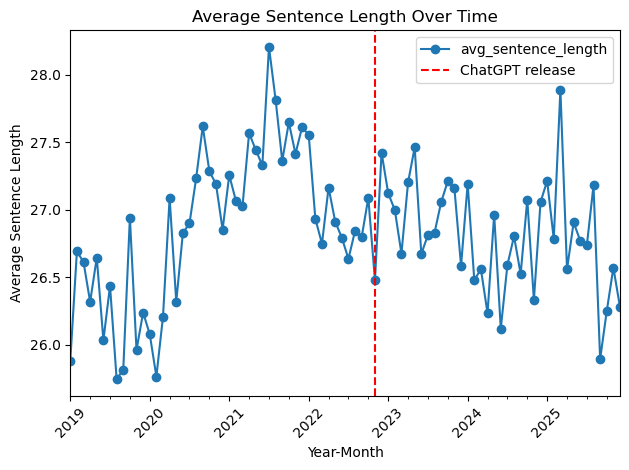

In [60]:
grouped = df_clean.groupby("year_month")["avg_sentence_length"].mean()

ax = grouped.plot(marker="o")

# Add vertical line at Nov 2022
ax.axvline(
    pd.Timestamp("2022-11-01"),
    color="red",
    linestyle="--",
    label="ChatGPT release"
)

ax.legend()
ax.set_xlabel("Year-Month")
ax.set_ylabel("Average Sentence Length")
ax.set_title("Average Sentence Length Over Time")

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

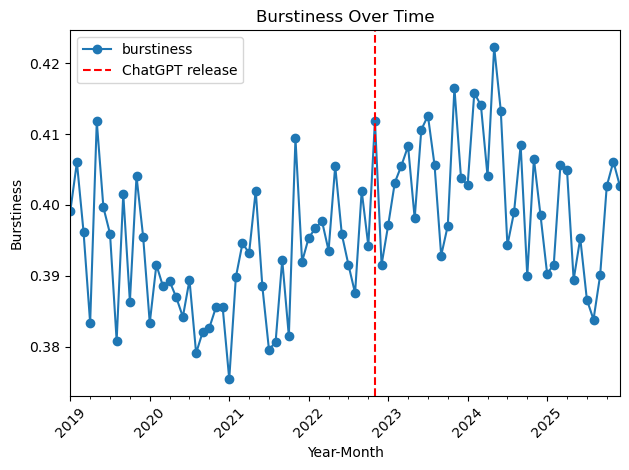

In [61]:
grouped = df_clean.groupby("year_month")["burstiness"].mean()

ax = grouped.plot(marker="o")

# Add vertical line at Nov 2022
ax.axvline(
    pd.Timestamp("2022-11-01"),
    color="red",
    linestyle="--",
    label="ChatGPT release"
)

ax.legend()
ax.set_xlabel("Year-Month")
ax.set_ylabel("Burstiness")
ax.set_title("Burstiness Over Time")

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

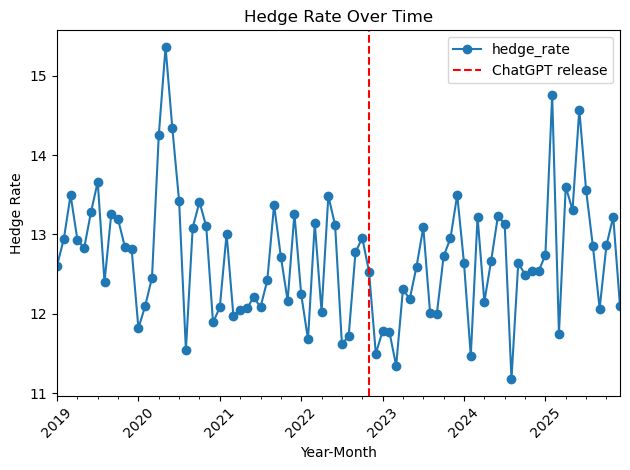

In [62]:
grouped = df_clean.groupby("year_month")["hedge_rate"].mean()

ax = grouped.plot(marker="o")

# Add vertical line at Nov 2022
ax.axvline(
    pd.Timestamp("2022-11-01"),
    color="red",
    linestyle="--",
    label="ChatGPT release"
)

ax.legend()
ax.set_xlabel("Year-Month")
ax.set_ylabel("Hedge Rate")
ax.set_title("Hedge Rate Over Time")

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

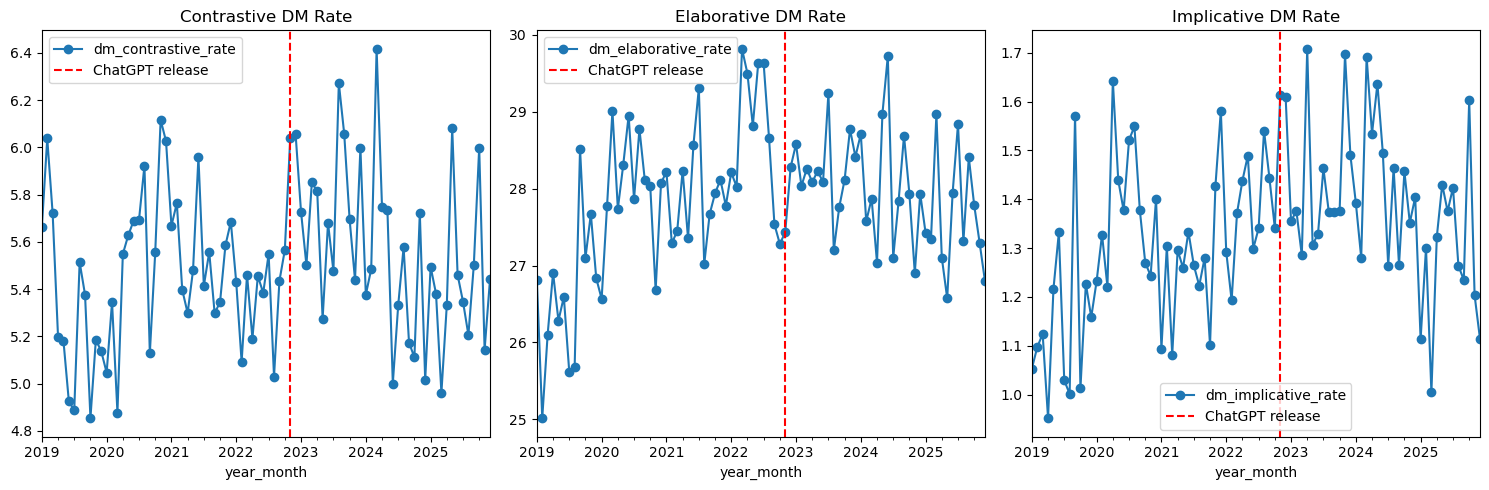

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(
    axes,
    ["dm_contrastive_rate", "dm_elaborative_rate", "dm_implicative_rate"],
    ["Contrastive DM Rate", "Elaborative DM Rate", "Implicative DM Rate"]
):
    
    df_clean.groupby("year_month")[col].mean().plot(
        marker="o", ax=ax, title=title
    )
    
    ax.axvline(
        pd.Timestamp("2022-11-01"),
        color="red",
        linestyle="--",
        label="ChatGPT release"
    )
    
    ax.legend()

plt.tight_layout()
plt.show()

In [64]:
df_clean.to_csv("post_processing_business.csv", index=False)

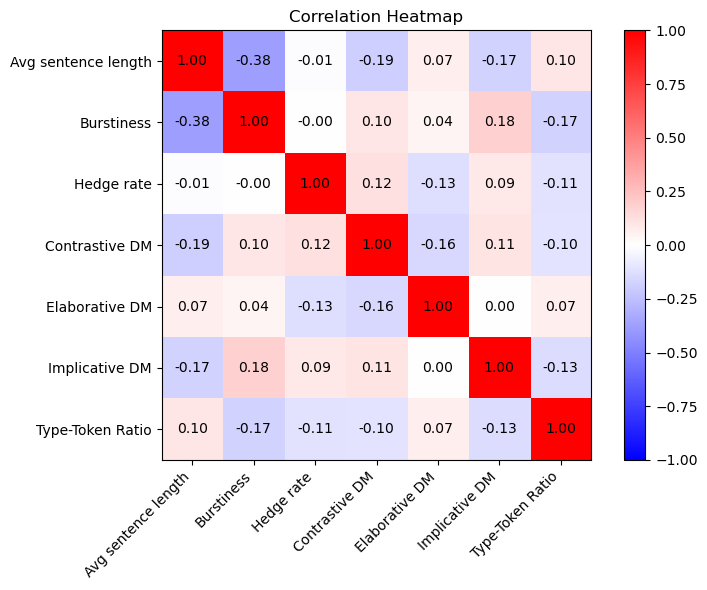

In [65]:
cols = [
    "avg_sentence_length",
    "burstiness",
    "hedge_rate",
    "dm_contrastive_rate",
    "dm_elaborative_rate",
    "dm_implicative_rate",
    "ttr"
]

label_map = {
    "avg_sentence_length": "Avg sentence length",
    "burstiness": "Burstiness",
    "hedge_rate": "Hedge rate",
    "dm_contrastive_rate": "Contrastive DM",
    "dm_elaborative_rate": "Elaborative DM",
    "dm_implicative_rate": "Implicative DM",
    "ttr": "Type-Token Ratio"
}

labels = [label_map[c] for c in cols]
corr = df_clean[cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    corr,
    cmap="bwr",
    vmin=-1, vmax=1
)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()